# Generating biological time courses with a conditional PyTorch GAN

The experiment learns dose-specific distributions of single-cell trajectories from the fixed training fold.

## 1. Setup and reproducibility

Install the repository with `python -m pip install -e ".[torch]"`. Model definitions and optimization are imported from the project package.

## Model and design decisions

Both variants are conditional GANs. A dose label is mapped to an integer and passed through an embedding; the embedding is concatenated to the generator noise and broadcast as extra channels in the discriminator. The same label therefore controls generation and the real/fake decision:

`(noise, dose) -> dose embedding -> Generator -> trajectory`  
`(trajectory, dose) -> Discriminator -> real/fake`

The dense layers create a global trajectory representation and one-dimensional convolutions refine local temporal structure. Variant A predicts all 289 points directly. Variant B predicts 100 coarse control points, upsamples them to 289 and applies convolutional refinement.

The original fixed `Normal(0, 0.5)` weight initialization was unsuitable here. Variance compounds through several dense and convolutional layers, producing initial outputs thousands of times larger than the data. `initialize_weights` therefore uses fan-in-dependent Kaiming initialization: for ReLU layers the weight standard deviation is approximately `sqrt(2 / fan_in)`, where `fan_in` is the number of incoming values per unit. Biases start at zero and the final output convolution uses linear gain.

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import pandas as pd

from deeplearning_examples.io import load_data
from pytorch_cdgan.model import Discriminator, Generator, count_parameters, initialize_weights
from pytorch_cdgan.training import GanTrainingConfig, train_gan

RANDOM_SEED = 32
NOISE_SIZE = 32
CONDITION_DIM = 3
torch.manual_seed(RANDOM_SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## 2. Load and inspect trajectories

The GAN is fitted only on the fixed `train` fold. Dose labels are converted to integer condition IDs; validate and test remain unused because this notebook performs no generative model selection.

trajectories: (2790, 289)
range: 0.005 to 4.313
dose counts: {np.str_('0pM'): np.int64(286), np.str_('1pM'): np.int64(621), np.str_('2.5pM'): np.int64(533), np.str_('5pM'): np.int64(487), np.str_('25pM'): np.int64(581), np.str_('100pM'): np.int64(282)}
year counts: {np.int64(2013): np.int64(1622), np.int64(2014): np.int64(1168)}


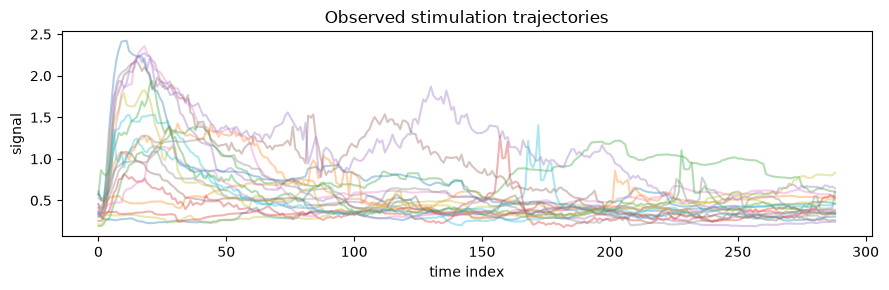

In [2]:
trajectories, doses, years = load_data("train")
dose_order = sorted(np.unique(doses), key=lambda value: float(value.removesuffix("pM")))
dose_names = np.asarray(dose_order)
dose_counts = np.asarray([(doses == dose).sum() for dose in dose_order])
dose_to_id = {name: index for index, name in enumerate(dose_names)}
condition_labels = np.asarray([dose_to_id[dose] for dose in doses], dtype=np.int64)
print(f"trajectories: {trajectories.shape}")
print(f"range: {trajectories.min():.3f} to {trajectories.max():.3f}")
print(f"dose counts: {dict(zip(dose_names, dose_counts))}")
year_names, year_counts = np.unique(years, return_counts=True)
print(f"year counts: {dict(zip(year_names, year_counts))}")
selection = np.random.default_rng(RANDOM_SEED).choice(len(trajectories), 20, replace=False)
plt.figure(figsize=(9, 3))
plt.plot(trajectories[selection].T, alpha=0.35)
plt.xlabel("time index")
plt.ylabel("signal")
plt.title("Observed stimulation trajectories")
plt.tight_layout()

## 3. Build conditional generators and discriminators

The dose embedding makes it possible to sample trajectories for a selected dose instead of only sampling the pooled distribution.

In [3]:
generator = Generator(noise_size=NOISE_SIZE, output_length=trajectories.shape[1], num_conditions=len(dose_names), condition_dim=CONDITION_DIM)
discriminator = Discriminator(input_length=trajectories.shape[1], num_conditions=len(dose_names), condition_dim=CONDITION_DIM)
generator.apply(initialize_weights)
discriminator.apply(initialize_weights)
print(f"generator parameters:     {count_parameters(generator):,}")
print(f"discriminator parameters: {count_parameters(discriminator):,}")
print(f"conditional generator: {len(dose_names)} doses, embedding={CONDITION_DIM}")

generator parameters:     121,908
discriminator parameters: 834,493
conditional generator: 6 doses, embedding=3


### Initial scale check

Before training, compare generated and observed ranges. A severe scale mismatch can make the discriminator's initial task trivial. The untrained curves are not expected to look biologically plausible yet; this check only verifies that initialization does not create exploding amplitudes.

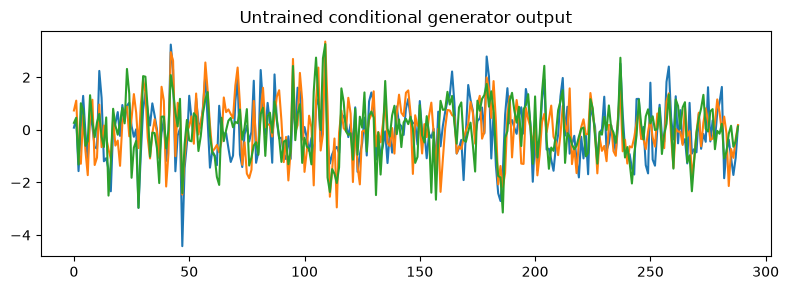

In [4]:
generator.eval()
with torch.no_grad():
    initial_labels = torch.arange(3) % len(dose_names)
    initial_samples = generator(torch.randn(3, NOISE_SIZE), initial_labels).squeeze(1).numpy()
plt.figure(figsize=(8, 3))
plt.plot(initial_samples.T)
plt.title("Untrained conditional generator output")
plt.tight_layout()

## 4. Adversarial training

`train_gan` performs separate discriminator and generator updates, records scalar diagnostics and periodically stores generated samples.

In [5]:
history = train_gan(
    generator,
    discriminator,
    trajectories,
    condition_labels=condition_labels,
    config=GanTrainingConfig(
        noise_size=NOISE_SIZE,
        epochs=3_00,
        batch_size=256,
        snapshot_every=100,
        report_every=50,
    ),
    device=device,
)

epoch    1: D(real)=0.661, D(fake)=0.445, G loss=0.941
epoch   50: D(real)=0.754, D(fake)=0.259, G loss=1.686
epoch  100: D(real)=0.624, D(fake)=0.374, G loss=1.196
epoch  150: D(real)=0.575, D(fake)=0.428, G loss=1.033
epoch  200: D(real)=0.543, D(fake)=0.485, G loss=0.794
epoch  250: D(real)=0.513, D(fake)=0.479, G loss=0.795
epoch  300: D(real)=0.508, D(fake)=0.484, G loss=0.751


## 4a. Training diagnostics

Discriminator scores near 0.5 indicate uncertainty, but not necessarily high-quality samples.

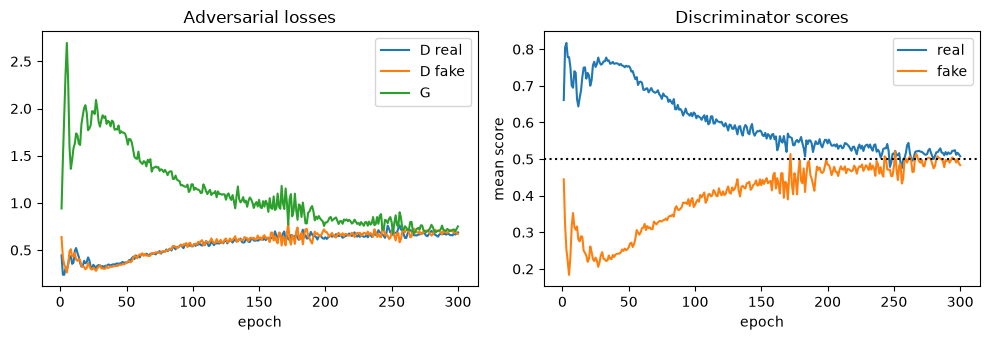

In [6]:
epochs = np.arange(1, len(history.generator_loss) + 1)
figure, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(epochs, history.discriminator_real_loss, label="D real")
axes[0].plot(epochs, history.discriminator_fake_loss, label="D fake")
axes[0].plot(epochs, history.generator_loss, label="G")
axes[0].set(title="Adversarial losses", xlabel="epoch")
axes[0].legend()
axes[1].plot(epochs, history.real_score, label="real")
axes[1].plot(epochs, history.fake_score, label="fake")
axes[1].axhline(0.5, color="black", linestyle=":")
axes[1].set(title="Discriminator scores", xlabel="epoch", ylabel="mean score")
axes[1].legend()
figure.tight_layout()

## 4b. Variant A diagnostics and statistics

Variant A predicts all timepoints directly. Its training diagnostics and feature distributions are inspected before introducing the coarse-to-fine model.

,mean signal,temporal std,maximum signal,dynamic range,endpoint change,mean absolute step
dose,,,,,,
0pM,0.362,0.065,0.546,0.312,0.034,0.007
1pM,0.374,0.077,0.610,0.377,0.003,0.012
2.5pM,0.447,0.185,1.145,0.924,-0.240,0.019
5pM,0.563,0.266,1.390,1.132,-0.260,0.020
25pM,0.728,0.304,1.663,1.383,-0.508,0.028
100pM,0.807,0.261,1.610,1.289,-0.107,0.019


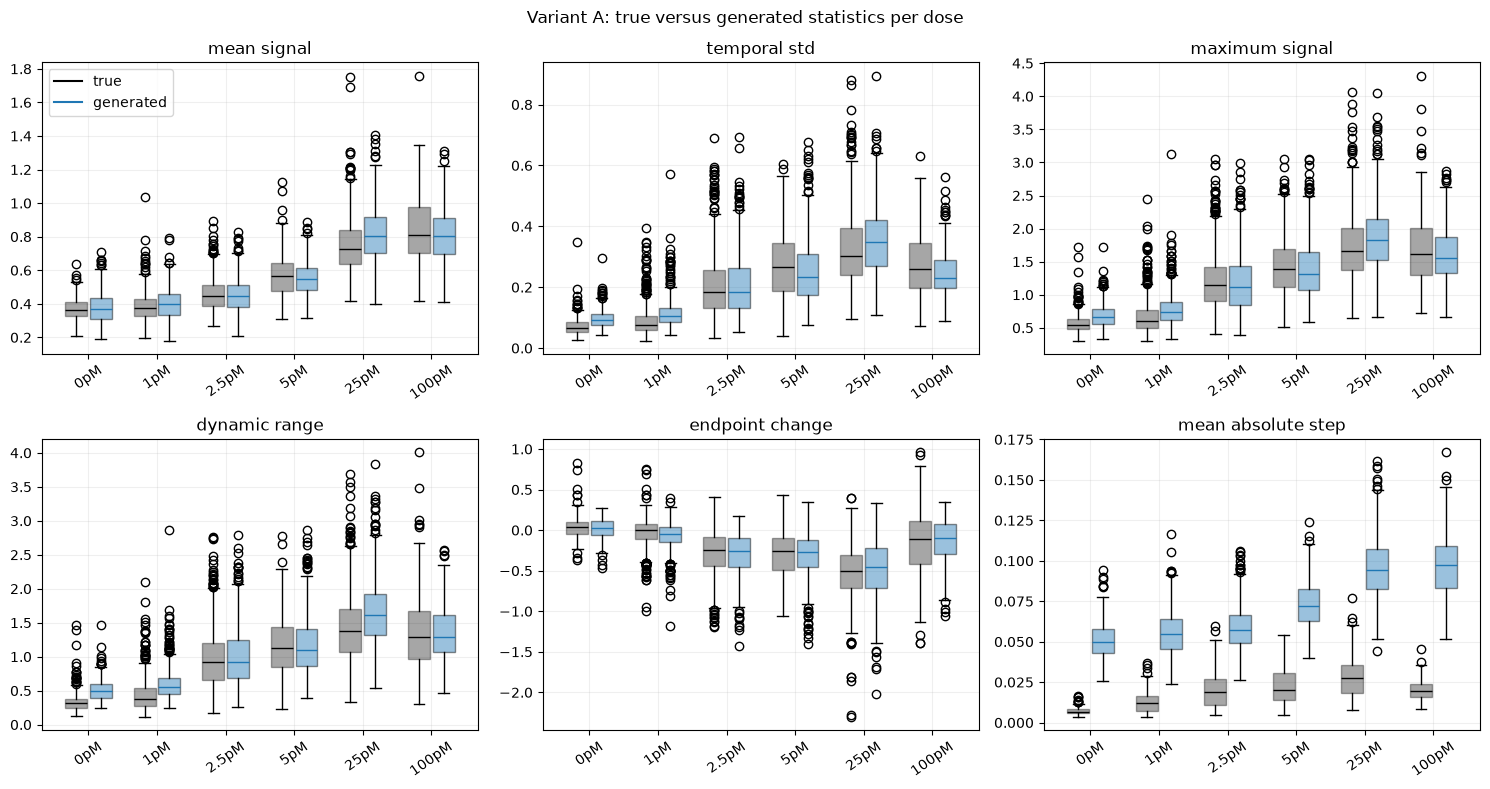

In [9]:
feature_columns = [
    "mean signal",
    "temporal std",
    "maximum signal",
    "dynamic range",
    "endpoint change",
    "mean absolute step",
]
dose_order = list(dose_names)

# Same definitions as 01_data_visualization: endpoint change compares
# the means of the final and initial 12 measurements.
true_features = pd.DataFrame({"dose": doses})
true_features["mean signal"] = trajectories.mean(axis=1)
true_features["temporal std"] = trajectories.std(axis=1)
true_features["maximum signal"] = trajectories.max(axis=1)
true_features["dynamic range"] = np.ptp(trajectories, axis=1)
true_features["endpoint change"] = trajectories[:, -12:].mean(axis=1) - trajectories[:, :12].mean(axis=1)
true_features["mean absolute step"] = np.abs(np.diff(trajectories, axis=1)).mean(axis=1)

def sample_model_by_dose(model):
    generated, labels = [], []
    model.eval()
    with torch.no_grad():
        for dose_id, n_samples in enumerate(dose_counts):
            labels_for_dose = torch.full((int(n_samples),), dose_id, dtype=torch.long, device=device)
            generated.append(model(torch.randn(int(n_samples), NOISE_SIZE, device=device), labels_for_dose).squeeze(1).cpu().numpy())
            labels.append(np.full(int(n_samples), dose_names[dose_id], dtype=object))
    return np.concatenate(generated), np.concatenate(labels)

def trajectory_features(x, labels):
    frame = pd.DataFrame({"dose": labels})
    frame["mean signal"] = x.mean(axis=1)
    frame["temporal std"] = x.std(axis=1)
    frame["maximum signal"] = x.max(axis=1)
    frame["dynamic range"] = np.ptp(x, axis=1)
    frame["endpoint change"] = x[:, -12:].mean(axis=1) - x[:, :12].mean(axis=1)
    frame["mean absolute step"] = np.abs(np.diff(x, axis=1)).mean(axis=1)
    return frame

def plot_feature_comparison(true_frame, generated_frame, title):
    fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=False)
    for feature, axis in zip(feature_columns, axes.flat):
        values = [
            [true_frame.loc[true_frame.dose == dose, feature].to_numpy() for dose in dose_order],
            [generated_frame.loc[generated_frame.dose == dose, feature].to_numpy() for dose in dose_order],
        ]
        positions = np.arange(len(dose_order))
        axis.boxplot(values[0], positions=positions - 0.18, widths=0.32, patch_artist=True,
                     boxprops={"facecolor": "black", "alpha": 0.35}, medianprops={"color": "black"})
        axis.boxplot(values[1], positions=positions + 0.18, widths=0.32, patch_artist=True,
                     boxprops={"facecolor": "tab:blue", "alpha": 0.45}, medianprops={"color": "tab:blue"})
        axis.set_title(feature)
        axis.set_xticks(positions, dose_order, rotation=35)
        axis.grid(alpha=0.2)
    axes[0, 0].plot([], [], color="black", label="true")
    axes[0, 0].plot([], [], color="tab:blue", label="generated")
    axes[0, 0].legend()
    fig.suptitle(title)
    fig.tight_layout()

generated_a, generated_a_doses = sample_model_by_dose(generator)
features_a = trajectory_features(generated_a, generated_a_doses)
plot_feature_comparison(true_features, features_a, "Variant A: true versus generated statistics per dose")
true_features.groupby("dose")[feature_columns].median().reindex(dose_order).round(3)

## 5. A coarse-to-fine generator with about 100 control points

The second generator uses `coarse_length=100`. It samples a 100-point latent trajectory, upsamples it linearly to 289 points and applies convolutional refinement. The discriminator still sees 289 points, so this is a structural smoothness prior rather than a change to the dataset resolution. The number of control points is a model parameter and can be compared across values such as 64, 100 and 144.

In [10]:
coarse_generator = Generator(
    noise_size=NOISE_SIZE,
    output_length=trajectories.shape[1],
    coarse_length=50,
    num_conditions=len(dose_names),
    condition_dim=CONDITION_DIM,
)
coarse_discriminator = Discriminator(
    input_length=trajectories.shape[1],
    num_conditions=len(dose_names),
    condition_dim=CONDITION_DIM,
)
coarse_generator.apply(initialize_weights)
coarse_discriminator.apply(initialize_weights)
print(f"coarse generator parameters: {count_parameters(coarse_generator):,}")

coarse_history = train_gan(
    coarse_generator,
    coarse_discriminator,
    trajectories,
    condition_labels=condition_labels,
    config=GanTrainingConfig(
        noise_size=NOISE_SIZE,
        epochs=2_000,
        batch_size=256,
        snapshot_every=100,
        report_every=50,
    ),
    device=device,
)

coarse generator parameters: 467,891
epoch    1: D(real)=0.743, D(fake)=0.658, G loss=0.678
epoch   50: D(real)=0.545, D(fake)=0.466, G loss=0.843
epoch  100: D(real)=0.528, D(fake)=0.475, G loss=0.820
epoch  150: D(real)=0.513, D(fake)=0.477, G loss=0.795
epoch  200: D(real)=0.541, D(fake)=0.479, G loss=0.776
epoch  250: D(real)=0.505, D(fake)=0.500, G loss=0.698
epoch  300: D(real)=0.503, D(fake)=0.502, G loss=0.691
Stopping after 307 epochs with stable discriminator scores.


## 5a. Training diagnostics

Discriminator scores near 0.5 indicate uncertainty, but not necessarily high-quality samples.

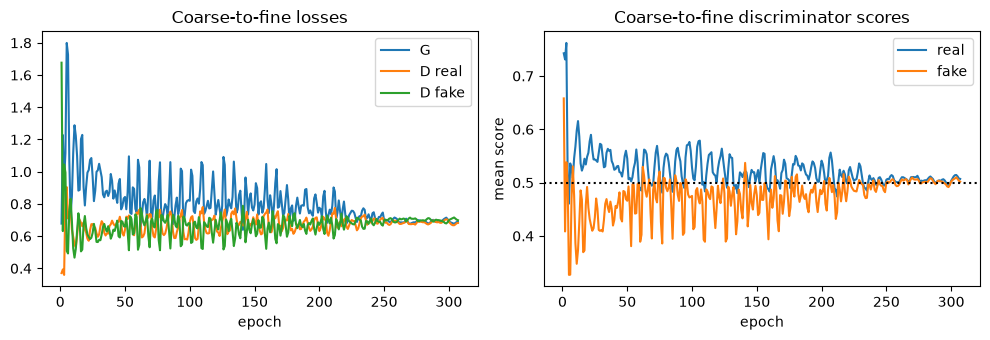

In [13]:
coarse_epochs = np.arange(1, len(coarse_history.generator_loss) + 1)
figure, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(coarse_epochs, coarse_history.generator_loss, label="G")
axes[0].plot(coarse_epochs, coarse_history.discriminator_real_loss, label="D real")
axes[0].plot(coarse_epochs, coarse_history.discriminator_fake_loss, label="D fake")
axes[0].set(title="Coarse-to-fine losses", xlabel="epoch")
axes[0].legend()
axes[1].plot(coarse_epochs, coarse_history.real_score, label="real")
axes[1].plot(coarse_epochs, coarse_history.fake_score, label="fake")
axes[1].axhline(0.5, color="black", linestyle=":")
axes[1].set(title="Coarse-to-fine discriminator scores", xlabel="epoch", ylabel="mean score")
axes[1].legend()
figure.tight_layout()

## 5b. Variant B diagnostics and statistics

Variant B predicts 100 control points before upsampling and convolutional refinement. This imposes a stronger smoothness prior.

,mean signal,temporal std,maximum signal,dynamic range,endpoint change,mean absolute step
dose,,,,,,
0pM,0.403,0.163,0.850,0.946,0.179,0.064
1pM,0.425,0.149,0.844,0.830,0.105,0.060
2.5pM,0.490,0.185,1.073,0.981,-0.165,0.060
5pM,0.625,0.279,1.425,1.342,-0.198,0.071
25pM,0.802,0.280,1.655,1.491,-0.384,0.083
100pM,0.901,0.249,1.681,1.415,-0.011,0.088


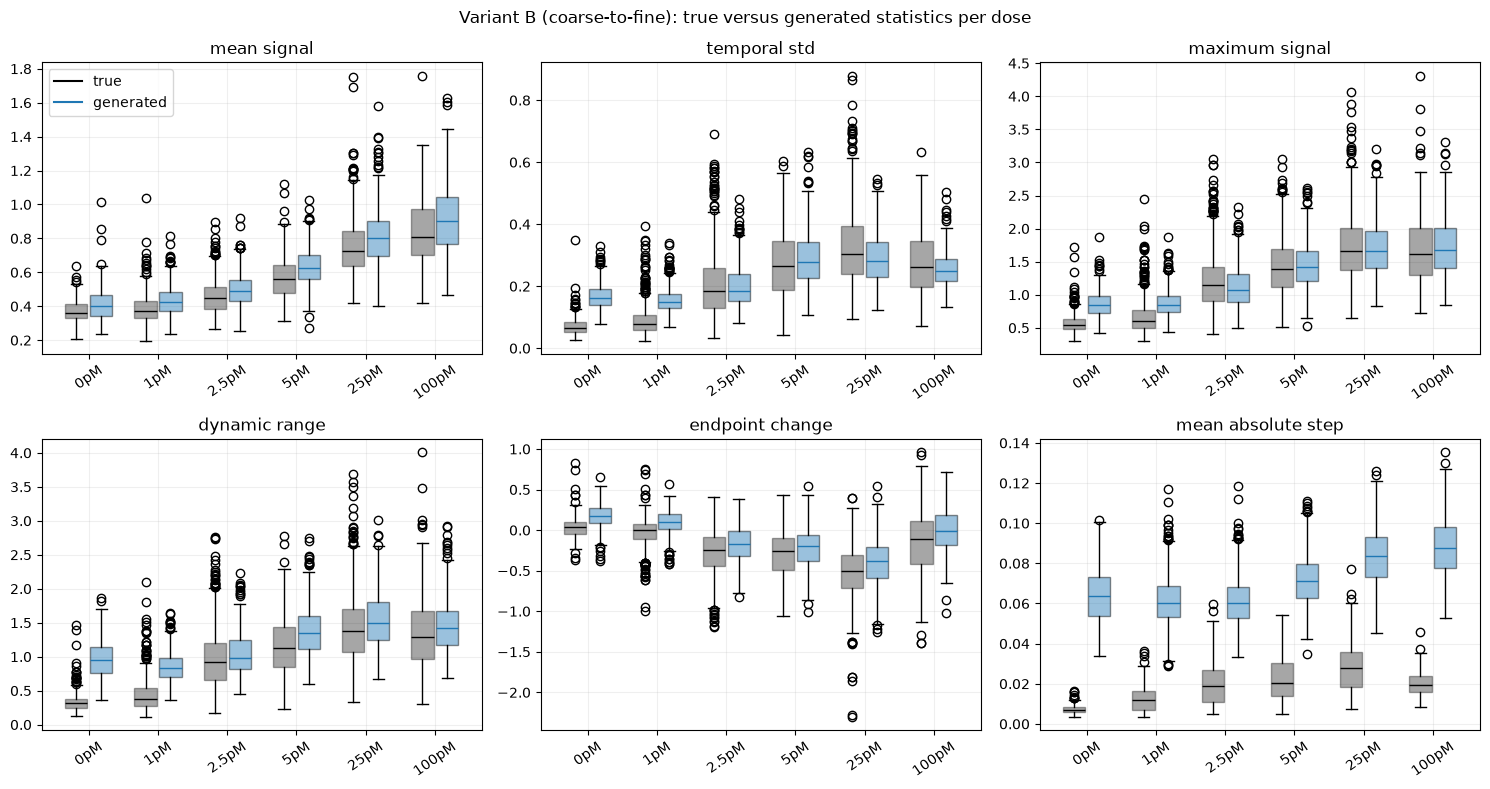

In [12]:
generated_b, generated_b_doses = sample_model_by_dose(coarse_generator)
features_b = trajectory_features(generated_b, generated_b_doses)
plot_feature_comparison(true_features, features_b, "Variant B (coarse-to-fine): true versus generated statistics per dose")
features_b.groupby("dose")[feature_columns].median().reindex(dose_order).round(3)

## 7. Generated trajectories over training

Snapshots reveal whether the generator learns plausible dynamics or collapses to a small set of shapes.

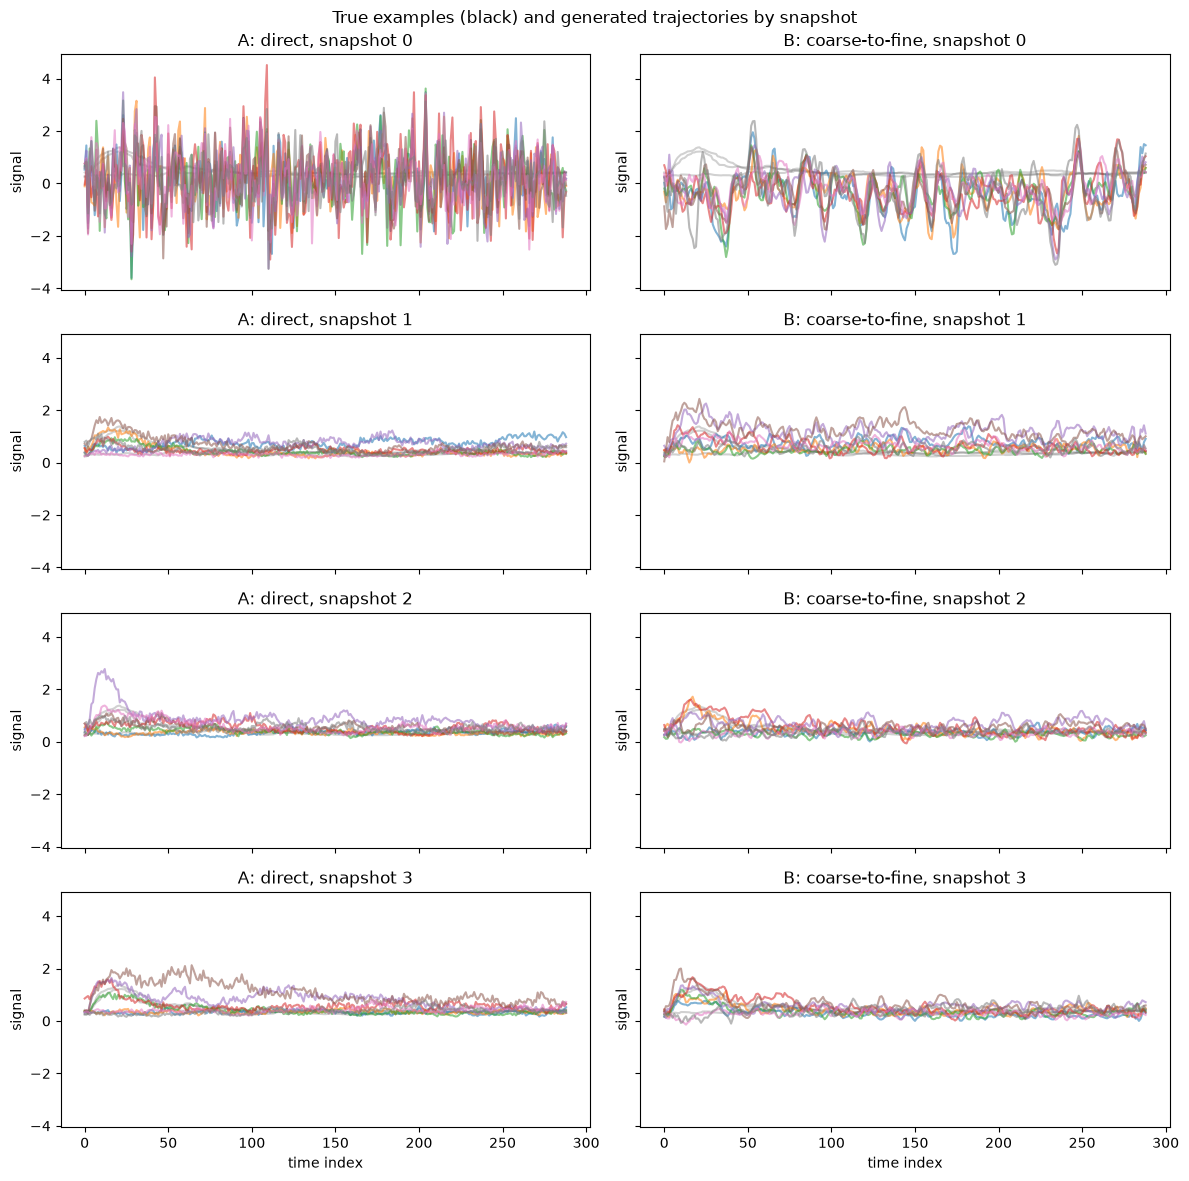

In [14]:
n_snapshots = min(len(history.snapshots), len(coarse_history.snapshots), 6)
fig, axes = plt.subplots(n_snapshots, 2, figsize=(12, 3 * n_snapshots), squeeze=False, sharex=True, sharey=True)
example_true = trajectories[np.random.default_rng(RANDOM_SEED).choice(len(trajectories), 3, replace=False)]
for row, snapshot_index in enumerate(np.linspace(0, n_snapshots - 1, n_snapshots, dtype=int)):
    for column, (name, snapshots) in enumerate((("A: direct", history.snapshots), ("B: coarse-to-fine", coarse_history.snapshots))):
        axis = axes[row, column]
        axis.plot(example_true.T, color="black", alpha=0.18)
        axis.plot(snapshots[snapshot_index].squeeze(1).T, alpha=0.55)
        axis.set_title(f"{name}, snapshot {snapshot_index}")
        axis.set_ylabel("signal")
axes[-1, 0].set_xlabel("time index")
axes[-1, 1].set_xlabel("time index")
fig.suptitle("True examples (black) and generated trajectories by snapshot")
fig.tight_layout()

## 8. Final comparison of true data and both variants

The same six feature definitions as in `01_data_visualization` are evaluated separately for each of the six dose steps. The final plot compares dose-wise medians for the true data, Variant A and Variant B.

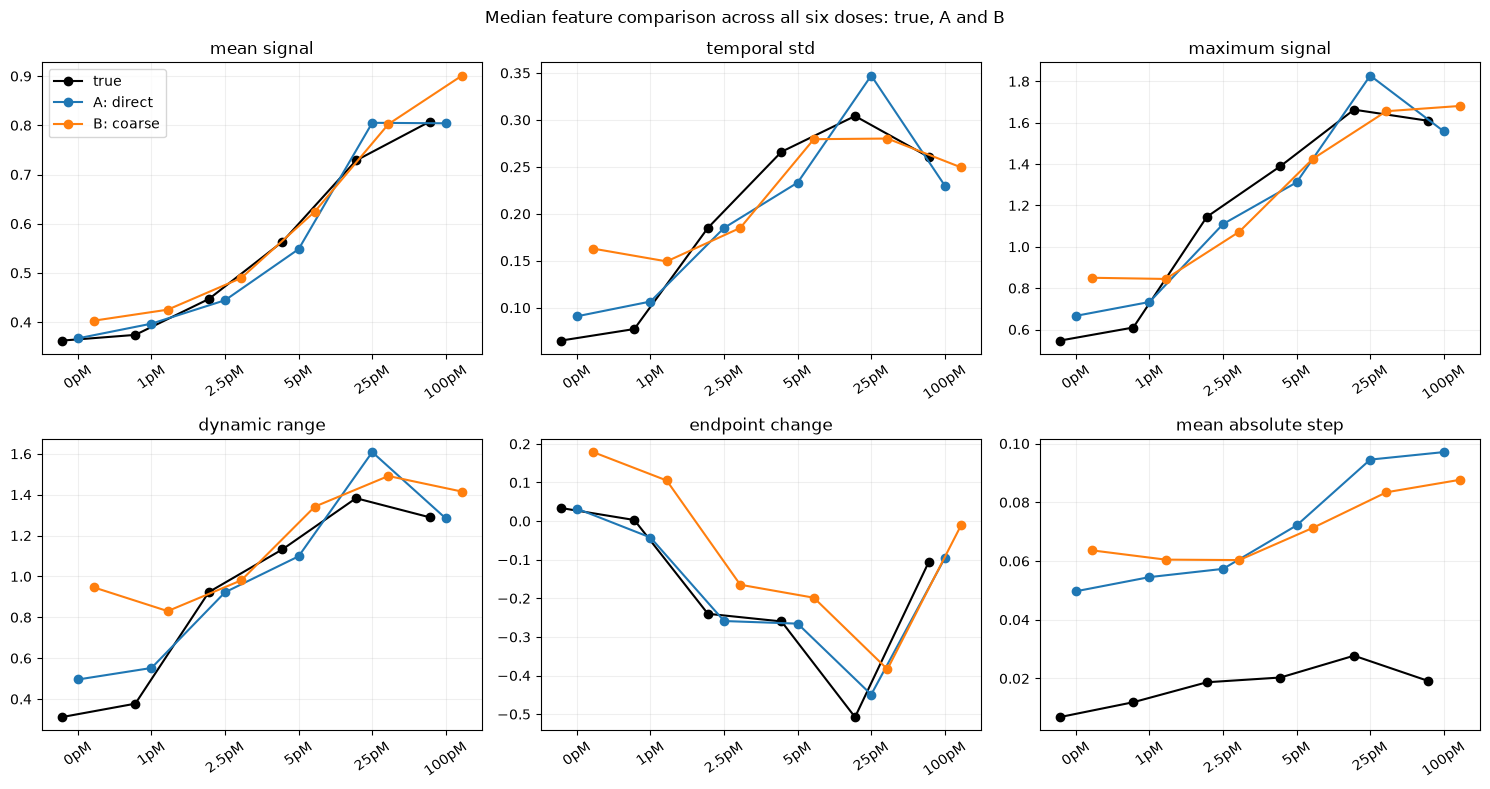

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for feature, axis in zip(feature_columns, axes.flat):
    positions = np.arange(len(dose_order))
    for offset, frame, color, label in [
        (-0.22, true_features, "black", "true"),
        (0.0, features_a, "tab:blue", "A: direct"),
        (0.22, features_b, "tab:orange", "B: coarse"),
    ]:
        medians = frame.groupby("dose")[feature].median().reindex(dose_order).to_numpy()
        axis.plot(positions + offset, medians, "o-", color=color, label=label)
    axis.set_title(feature)
    axis.set_xticks(positions, dose_order, rotation=35)
    axis.grid(alpha=0.2)
axes[0, 0].legend()
fig.suptitle("Median feature comparison across all six doses: true, A and B")
fig.tight_layout()

### Dose-specific sampling

The condition is active at sampling time: here both generators receive the same selected dose label.

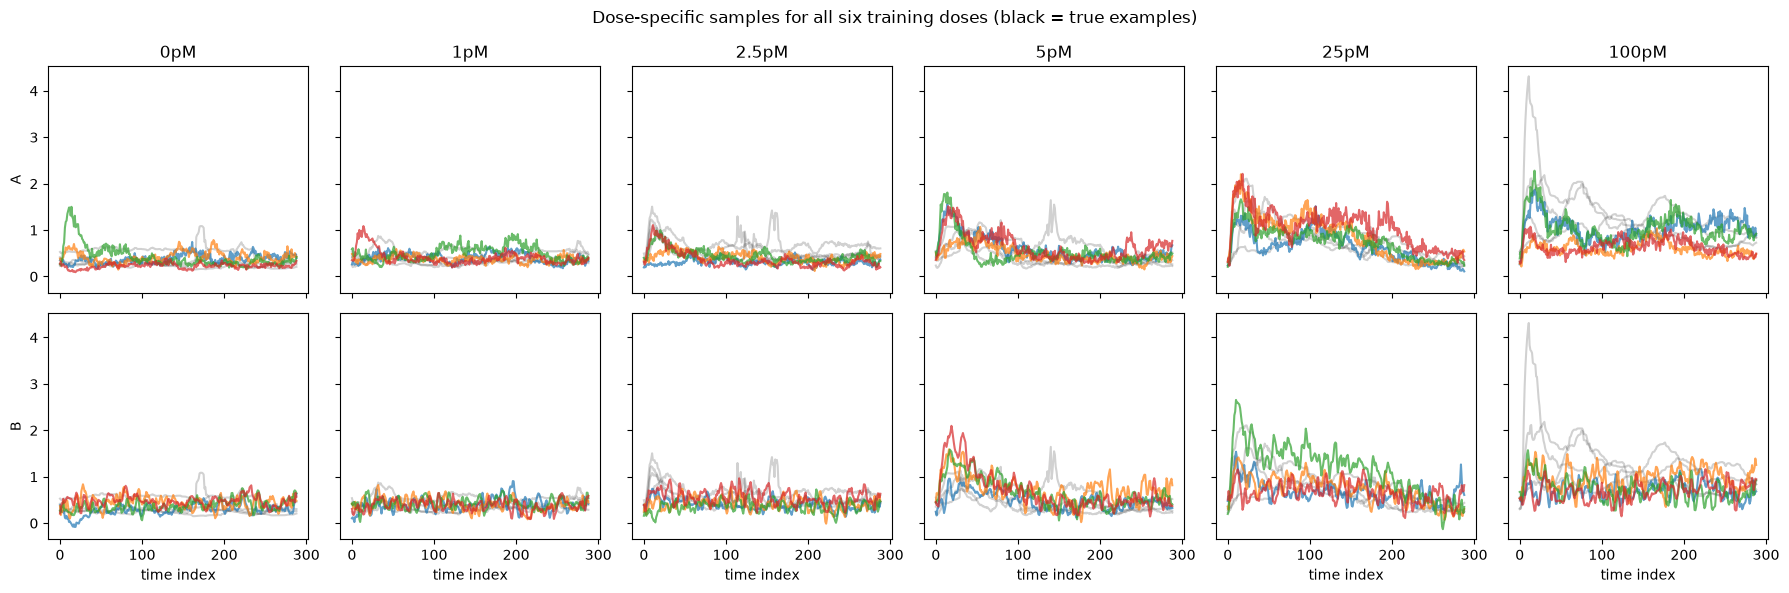

In [16]:
n_examples = 4
fig, axes = plt.subplots(2, len(dose_order), figsize=(18, 6), sharex=True, sharey=True)
rng = np.random.default_rng(RANDOM_SEED)
for dose_id, dose in enumerate(dose_order):
    true_examples = trajectories[np.asarray(doses) == dose][rng.choice(np.sum(np.asarray(doses) == dose), n_examples, replace=False)]
    labels_for_dose = torch.full((n_examples,), dose_id, dtype=torch.long, device=device)
    with torch.no_grad():
        sample_a = generator(torch.randn(n_examples, NOISE_SIZE, device=device), labels_for_dose).squeeze(1).cpu().numpy()
        sample_b = coarse_generator(torch.randn(n_examples, NOISE_SIZE, device=device), labels_for_dose).squeeze(1).cpu().numpy()
    axes[0, dose_id].plot(true_examples.T, color="black", alpha=0.18)
    axes[0, dose_id].plot(sample_a.T, alpha=0.7)
    axes[1, dose_id].plot(true_examples.T, color="black", alpha=0.18)
    axes[1, dose_id].plot(sample_b.T, alpha=0.7)
    axes[0, dose_id].set_title(str(dose))
    axes[0, dose_id].set_ylabel("A" if dose_id == 0 else "")
    axes[1, dose_id].set_ylabel("B" if dose_id == 0 else "")
for axis in axes[-1]: axis.set_xlabel("time index")
fig.suptitle("Dose-specific samples for all six training doses (black = true examples)")
fig.tight_layout()

## 9. Next Steps

* **Roughness loss and dose conditioning:** A derivative or roughness loss compares temporal differences, for example `L_rough = |std(diff(fake)) - std(diff(real))|` (optionally also matching the mean absolute first derivative). It discourages frame-to-frame jitter and can make generated curves smoother, but a large weight erases genuine sharp peaks and reduces diversity. It should therefore be a small auxiliary generator term, not a replacement for the adversarial loss.

## 10. Interpretation

Useful follow-up diagnostics include nearest-neighbor checks against the training set, diversity metrics and comparisons of burst frequency, amplitude and duration. A plausible-looking mean trajectory alone is insufficient evidence that the generator learned the biological distribution.